# Ultimate Games Dataset — Complete Exploratory Data Analysis

**15,000 games | 43 features | 1979 to 2026**

---

This notebook walks through the entire dataset from top to bottom. By the end, you will know exactly what every column means, what the data looks like numerically and visually, and where the most interesting signals are for building models or running further analysis.

### What this notebook covers

1. Dataset overview and column guide
2. Missing value audit
3. Numeric feature distributions
4. Categorical feature breakdowns
5. Temporal trends (releases by year and decade)
6. Rating analysis — user scores vs. Metacritic
7. Engagement and popularity
8. Platform and genre landscape
9. Correlation heatmap
10. Key takeaways and ideas for next steps

---

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Consistent style across all plots
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlepad'] = 12

df = pd.read_csv('/kaggle/input/datasets/rudrakumargupta/ultimate-games-dataset-15k-games-43-features/Ultimate_Games_Dataset.csv')

print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')
df.head(3)

Rows    : 15,000
Columns : 43


,serial_no,game_id,title,release_date,release_year,all_genres,theme,art_style,view_dimension,game_mode,...,cover_image_url,official_website,url_slug,description_clean,popularity_score,engagement_score,decade,is_multi_platform,rating_tier,metacritic_tier
0,1,3498,Grand Theft Auto V,2013-09-17,2013.0,Action,Crime,Realistic,3D,Single & Multiplayer,...,https://media.rawg.io/media/games/20a/20aa03a1...,http://www.rockstargames.com/V/,grand-theft-auto-v,"Rockstar Games went bigger, since their previo...",96.28,21.75,2010s,1,excellent,universal_acclaim
1,2,3328,The Witcher 3: Wild Hunt,2015-05-18,2015.0,Action|RPG,Fantasy,Realistic,3D,Singleplayer,...,https://media.rawg.io/media/games/618/618c2031...,https://thewitcher.com/en/witcher3,the-witcher-3-wild-hunt,"The third game in a series, it holds nothing b...",95.81,17.19,2010s,1,masterpiece,universal_acclaim
2,3,4200,Portal 2,2011-04-18,2011.0,Shooter|Puzzle,Sci-Fi,Realistic,3D,Single & Multiplayer,...,https://media.rawg.io/media/games/2ba/2bac0e87...,http://www.thinkwithportals.com/,portal-2,Portal 2 is a first-person puzzle game develop...,91.26,15.24,2010s,1,masterpiece,universal_acclaim


---
## 2. Column Reference Guide

The dataset has 43 columns split into seven logical groups.

### Identity
| Column | Type | Description |
|---|---|---|
| `serial_no` | int | Row index (1-based) |
| `game_id` | int | Unique game identifier from RAWG |
| `title` | str | Official game title |
| `url_slug` | str | URL-friendly version of the title |
| `cover_image_url` | str | Link to the cover art image |
| `official_website` | str | Developer/publisher official site |
| `description_clean` | str | Plain-text game description |

### Release
| Column | Type | Description |
|---|---|---|
| `release_date` | str | Full release date (YYYY-MM-DD) |
| `release_year` | float | Year extracted from release date |
| `decade` | str | Decade bucket (1980s, 1990s, 2000s, 2010s, 2020s) |

### Game Metadata
| Column | Type | Description |
|---|---|---|
| `all_genres` | str | Pipe-separated genre list (e.g. Action|RPG) |
| `theme` | str | Narrative/visual theme (Sci-Fi, Fantasy, Horror, etc.) |
| `art_style` | str | Visual art direction (Realistic, Anime, Pixel Art, etc.) |
| `view_dimension` | str | 2D, 3D, or mixed |
| `game_mode` | str | Singleplayer, Multiplayer, or both |
| `is_multiplayer` | int | Binary flag (1 = has multiplayer) |
| `controls` | str | Input method (Controller, Keyboard/Mouse, etc.) |
| `esrb_rating` | str | ESRB content rating |
| `all_tags` | str | Pipe-separated community tags |
| `avg_playtime_hours` | float | Average hours to complete |
| `achievements_count` | float | Number of in-game achievements |
| `game_series_count` | float | Number of games in the same series |

### Studio / Distribution
| Column | Type | Description |
|---|---|---|
| `developers` | str | Pipe-separated developer studio names |
| `publishers` | str | Pipe-separated publisher names |
| `all_platforms` | str | Pipe-separated platform list |
| `platform_count` | float | Number of platforms the game is on |
| `is_multi_platform` | int | Binary flag (1 = on more than one platform) |
| `available_stores` | str | Digital storefronts where the game is sold |

### Ratings
| Column | Type | Description |
|---|---|---|
| `user_rating` | float | Aggregate user score (1.0 to 5.0) |
| `metacritic` | float | Metacritic critic score (0 to 100) |
| `rating_tier` | str | Derived label for user_rating (masterpiece, excellent, good, average, below_average, unrated) |
| `metacritic_tier` | str | Derived label for metacritic (universal_acclaim, generally_favorable, mixed, generally_unfavorable, no_score) |

### Community Activity
| Column | Type | Description |
|---|---|---|
| `ratings_count` | float | Total number of user ratings submitted |
| `reviews_count` | float | Total number of written user reviews |
| `library_count` | float | Users who have the game in their library |
| `status_owned` | int | Users who marked the game as owned |
| `status_beaten` | int | Users who completed the game |
| `status_playing` | int | Users currently playing |
| `status_dropped` | int | Users who abandoned the game |
| `status_toplay` | int | Users who added it to a play-later list |
| `status_yet` | int | Users who have not started it yet |

### Derived Scores
| Column | Type | Description |
|---|---|---|
| `popularity_score` | float | Engineered score combining library size and rating volume |
| `engagement_score` | float | Engineered score based on reviews, completion rate, and playtime |

---
## 3. Missing Value Audit

Columns with missing values:
             missing_count  missing_pct
metacritic             886         5.91
user_rating            387         2.58


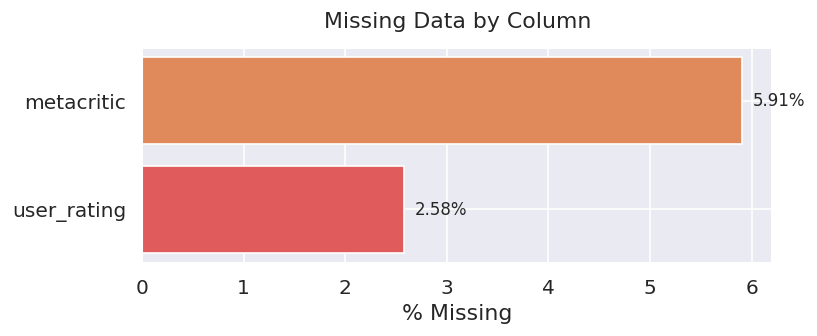

In [2]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

print('Columns with missing values:')
print(pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}))

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(missing.index[::-1], missing_pct.values[::-1], color=['#e05c5c', '#e08a5c'])
ax.set_xlabel('% Missing')
ax.set_title('Missing Data by Column')
for i, v in enumerate(missing_pct.values[::-1]):
    ax.text(v + 0.1, i, f'{v}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

**Notes on missing data:**
- `metacritic` is missing for 5.9% of games (886 rows). These are games that either never received enough critic reviews or were not indexed by Metacritic. The `metacritic_tier` column labels these as `no_score`.
- `user_rating` is missing for 2.6% of games (387 rows). These are typically very obscure or very newly released titles with no user activity. The `rating_tier` column labels these as `unrated`.
- All other 41 columns are complete with zero missing values.

---
## 4. Numeric Feature Distributions

In [3]:
numeric_cols = [
    'user_rating', 'metacritic', 'ratings_count', 'reviews_count',
    'library_count', 'avg_playtime_hours', 'achievements_count',
    'popularity_score', 'engagement_score', 'platform_count'
]

df[numeric_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
user_rating,14613.0,3.27,0.71,1.00,2.81,3.43,3.80,5.00
metacritic,14114.0,70.72,8.14,23.00,66.00,70.00,75.10,99.00
ratings_count,15000.0,105.17,319.70,0.00,2.00,17.00,68.00,7153.00
reviews_count,15000.0,104.72,320.63,0.00,1.00,15.00,68.00,7268.00
library_count,15000.0,745.55,1506.65,0.00,11.00,281.00,743.00,22126.00
avg_playtime_hours,15000.0,3.72,8.88,0.00,1.00,3.00,4.00,367.00
achievements_count,15000.0,52.60,213.82,0.00,0.00,10.00,49.00,7166.00
popularity_score,15000.0,24.93,10.23,1.61,20.23,26.50,30.80,96.28
engagement_score,15000.0,3.81,5.68,0.00,0.45,1.83,4.25,41.93
platform_count,15000.0,2.60,1.87,1.00,1.00,2.00,3.00,22.00


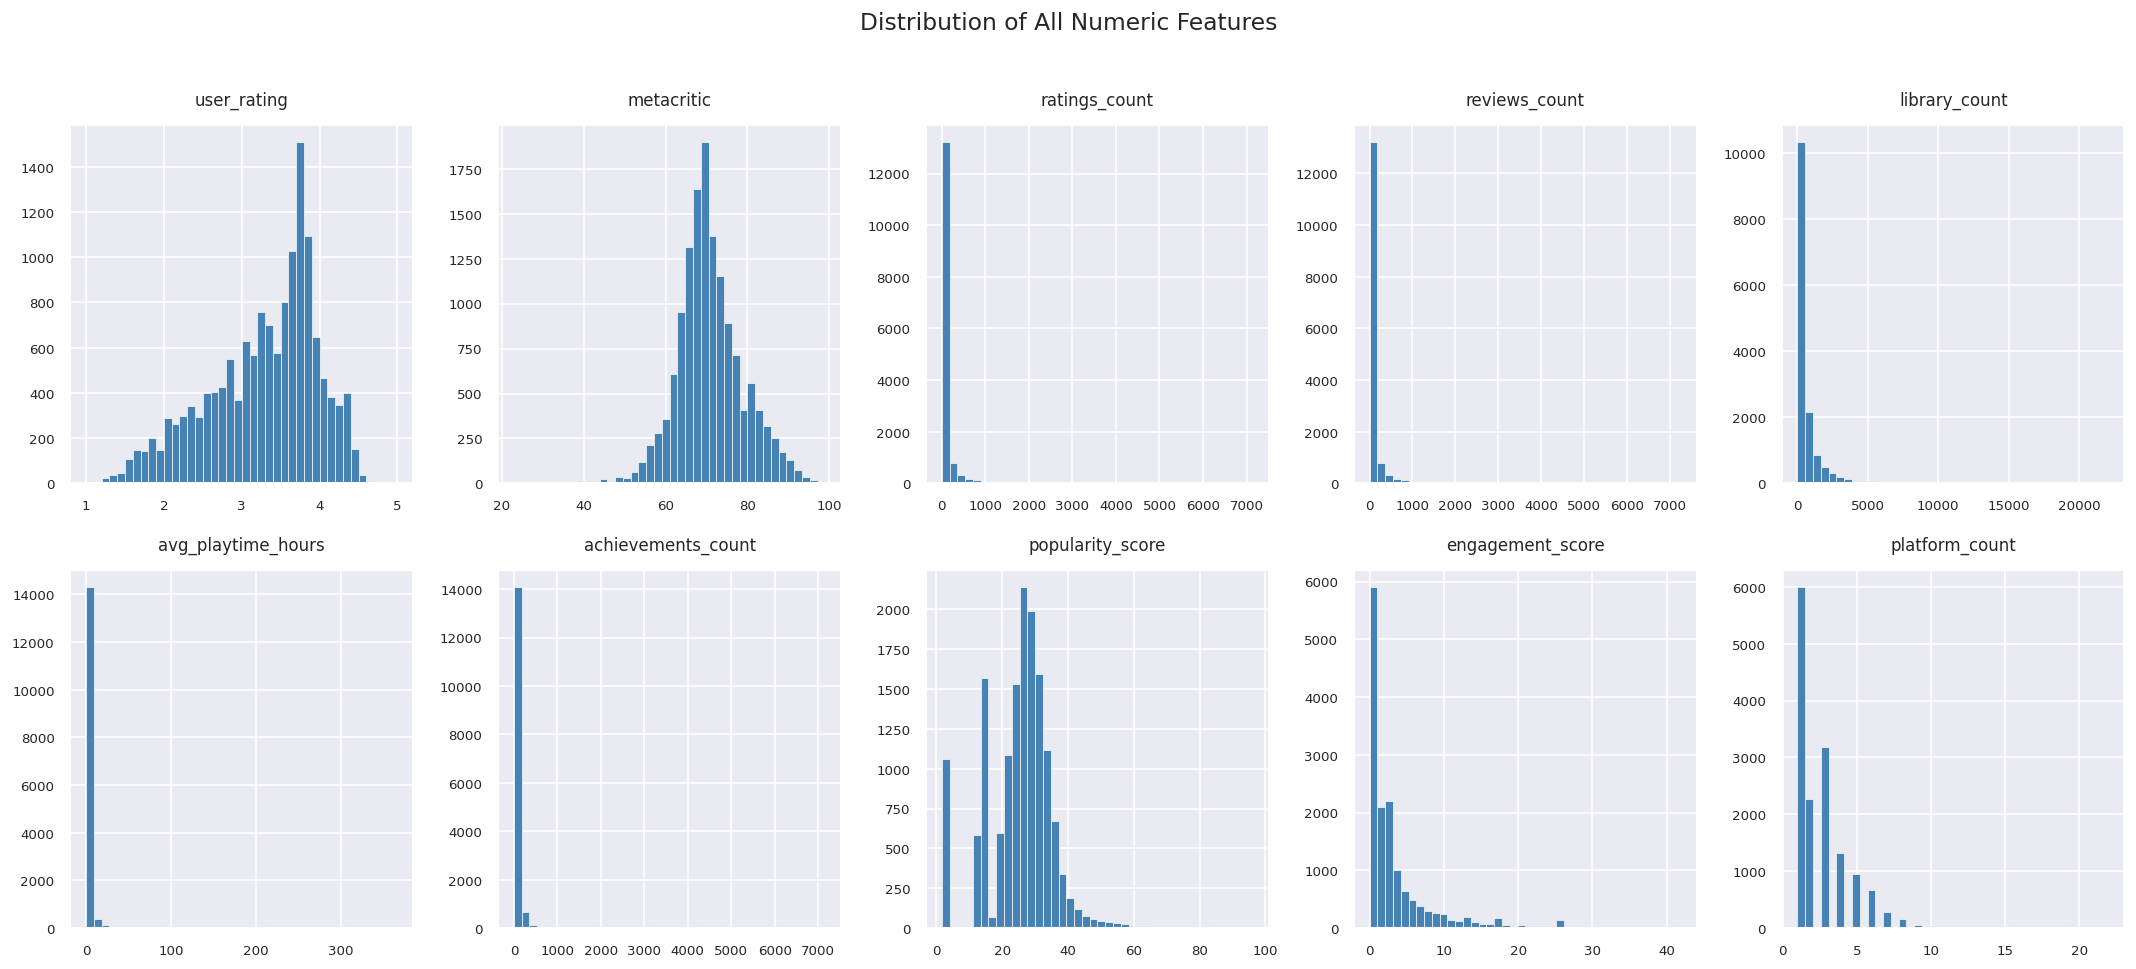

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=8)

plt.suptitle('Distribution of All Numeric Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**What to observe:**
- `user_rating` clusters between 3.0 and 4.0 — very few games are rated below 2 or above 4.5.
- `metacritic` is roughly bell-shaped centered around 70, consistent with industry-wide norms.
- `ratings_count`, `library_count`, `reviews_count`, `popularity_score`, and `engagement_score` are all heavily right-skewed. A small number of blockbuster titles dominate these counts. Log-transforming before modeling is recommended.
- `avg_playtime_hours` is also skewed. Most games are beaten in under 20 hours, but a long tail exists for RPGs and open-world games.
- `platform_count` is discrete and peaks at 1 and 2.

---
## 5. Categorical Feature Breakdowns

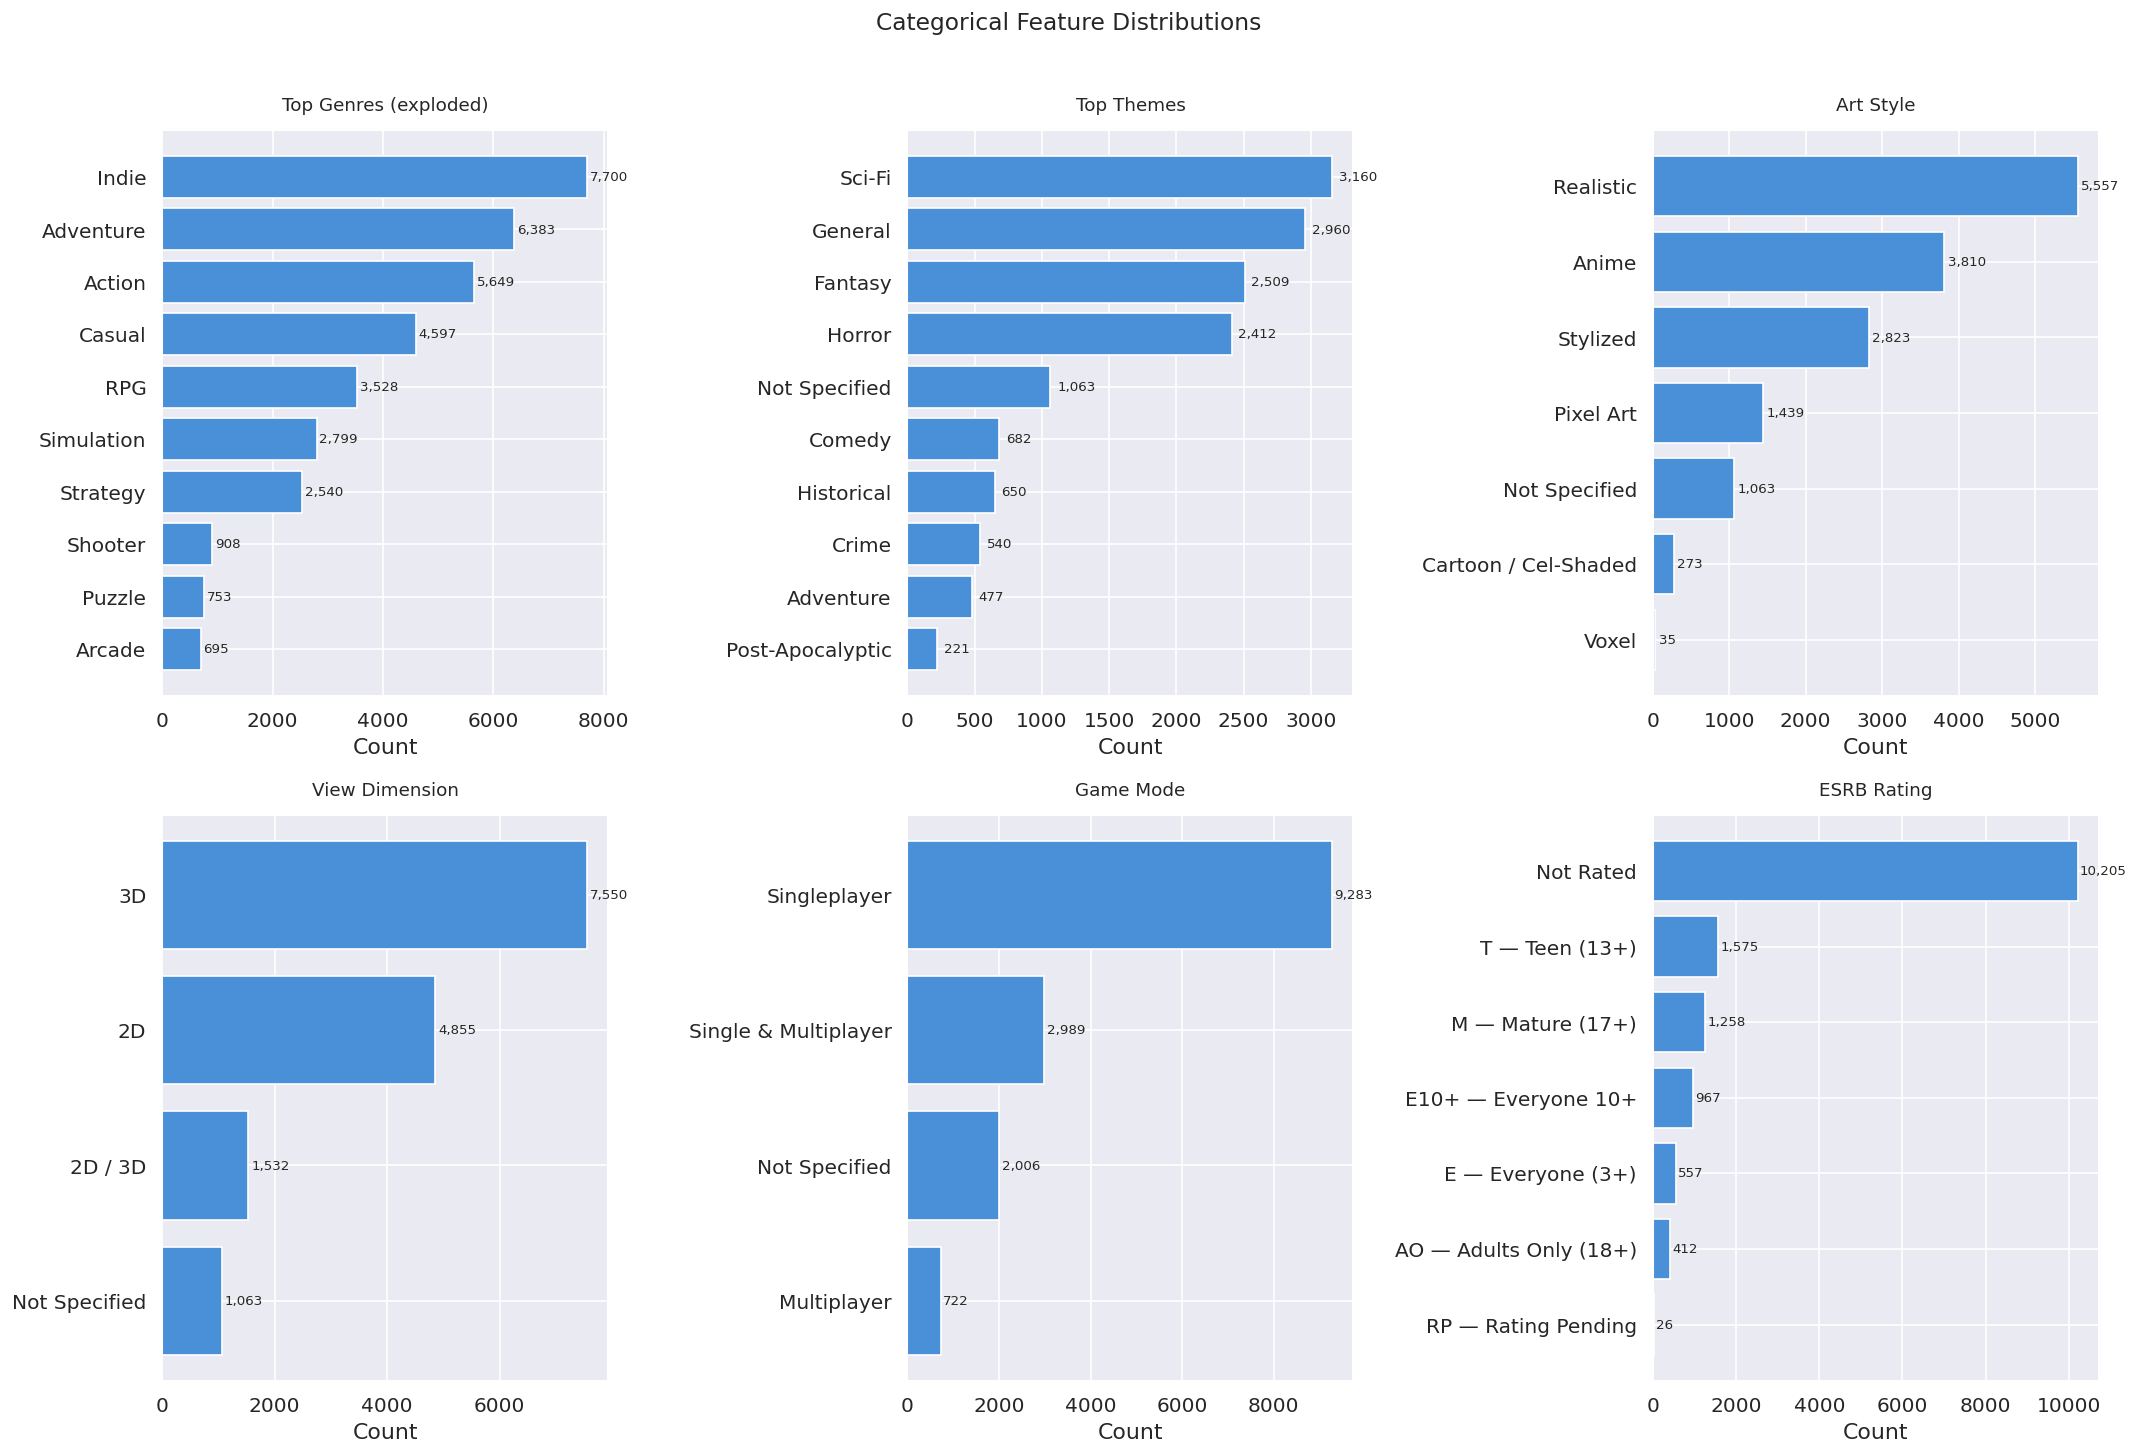

In [5]:
def plot_value_counts(col, ax, title, top_n=10, pipe_split=False):
    if pipe_split:
        series = df[col].dropna().str.split('|').explode().str.strip()
    else:
        series = df[col].dropna()
    counts = series.value_counts().head(top_n)
    ax.barh(counts.index[::-1], counts.values[::-1], color='#4a90d9')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Count')
    for i, v in enumerate(counts.values[::-1]):
        ax.text(v + 50, i, f'{v:,}', va='center', fontsize=8)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

plot_value_counts('all_genres',    axes[0,0], 'Top Genres (exploded)',   pipe_split=True)
plot_value_counts('theme',         axes[0,1], 'Top Themes',              top_n=10)
plot_value_counts('art_style',     axes[0,2], 'Art Style')
plot_value_counts('view_dimension',axes[1,0], 'View Dimension')
plot_value_counts('game_mode',     axes[1,1], 'Game Mode')
plot_value_counts('esrb_rating',   axes[1,2], 'ESRB Rating')

plt.suptitle('Categorical Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Key observations:**
- **Genres:** Indie dominates with 7,700 occurrences, followed by Adventure and Action. This reflects the explosion of independent game development since 2010.
- **Theme:** Sci-Fi, General, Fantasy, and Horror are the four most common narrative themes. Together they cover over 73% of games.
- **Art Style:** Realistic (37%) and Anime (25%) are the two largest art style categories.
- **View Dimension:** 3D games (50%) outnumber 2D games (32%).
- **Game Mode:** The majority are singleplayer-only (62%). Roughly 20% support both modes.
- **ESRB Rating:** More than 68% of games are listed as "Not Rated", which typically means the game was released outside North America or was too niche to receive a rating. Among rated games, Teen is the most common category.

---
## 6. Temporal Trends

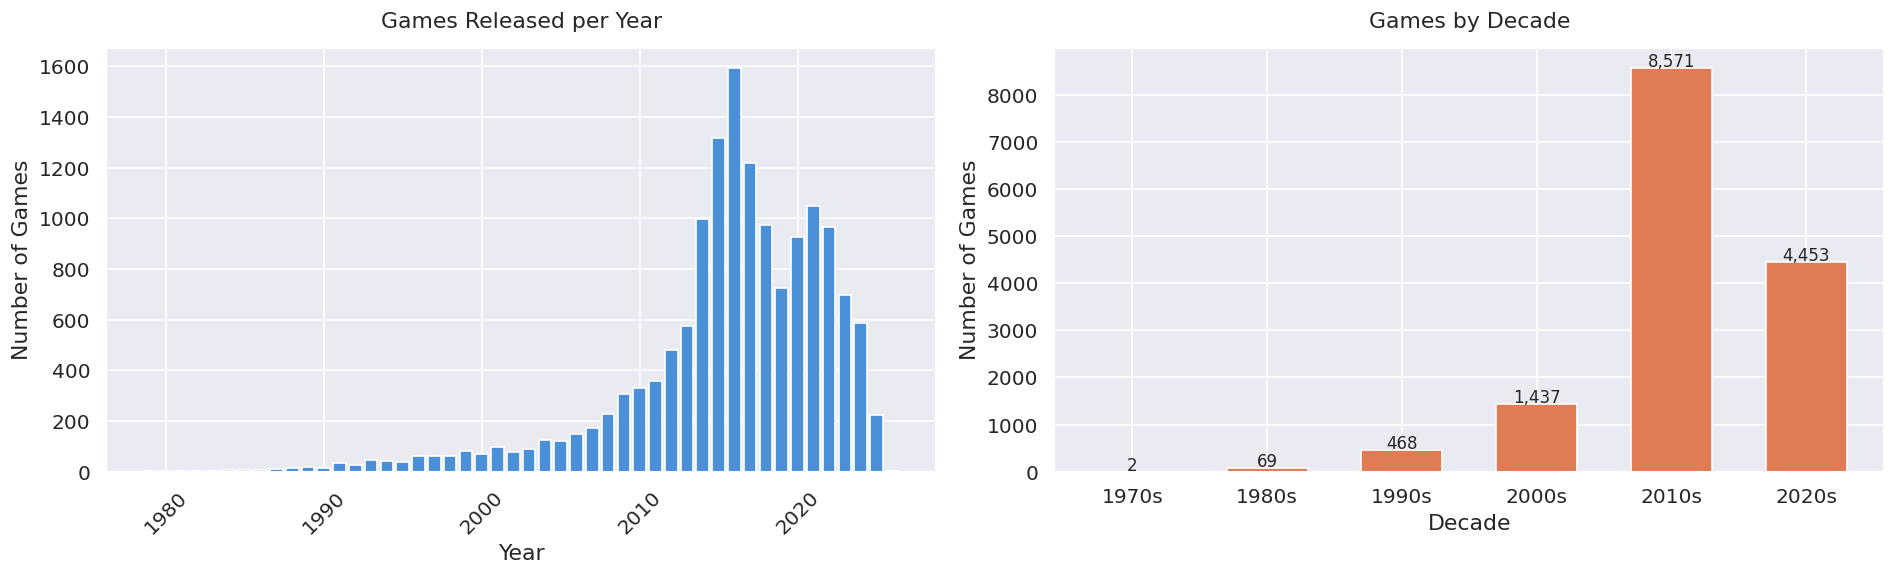

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Games per year
year_counts = df['release_year'].dropna().astype(int).value_counts().sort_index()
axes[0].bar(year_counts.index, year_counts.values, color='#4a90d9', width=0.8)
axes[0].set_title('Games Released per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Games')
axes[0].tick_params(axis='x', rotation=45)

# Games per decade
decade_order = ['1970s','1980s','1990s','2000s','2010s','2020s']
decade_counts = df['decade'].value_counts().reindex(decade_order).dropna()
axes[1].bar(decade_counts.index, decade_counts.values, color='#e07b54', width=0.6)
axes[1].set_title('Games by Decade')
axes[1].set_xlabel('Decade')
axes[1].set_ylabel('Number of Games')
for i, (x, y) in enumerate(zip(decade_counts.index, decade_counts.values)):
    axes[1].text(i, y + 30, f'{y:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

**Key observations:**
- The dataset spans from 1979 to 2026, but 57% of all games (8,571) were released in the 2010s.
- The steep rise in yearly releases from 2010 onward corresponds with the democratization of game development tools (Unity, Unreal Engine, GameMaker) and the rise of digital storefronts (Steam, itch.io).
- The 2020s already account for 4,453 games despite the decade being only a few years in, suggesting the pace of releases is still accelerating.

---
## 7. Rating Analysis

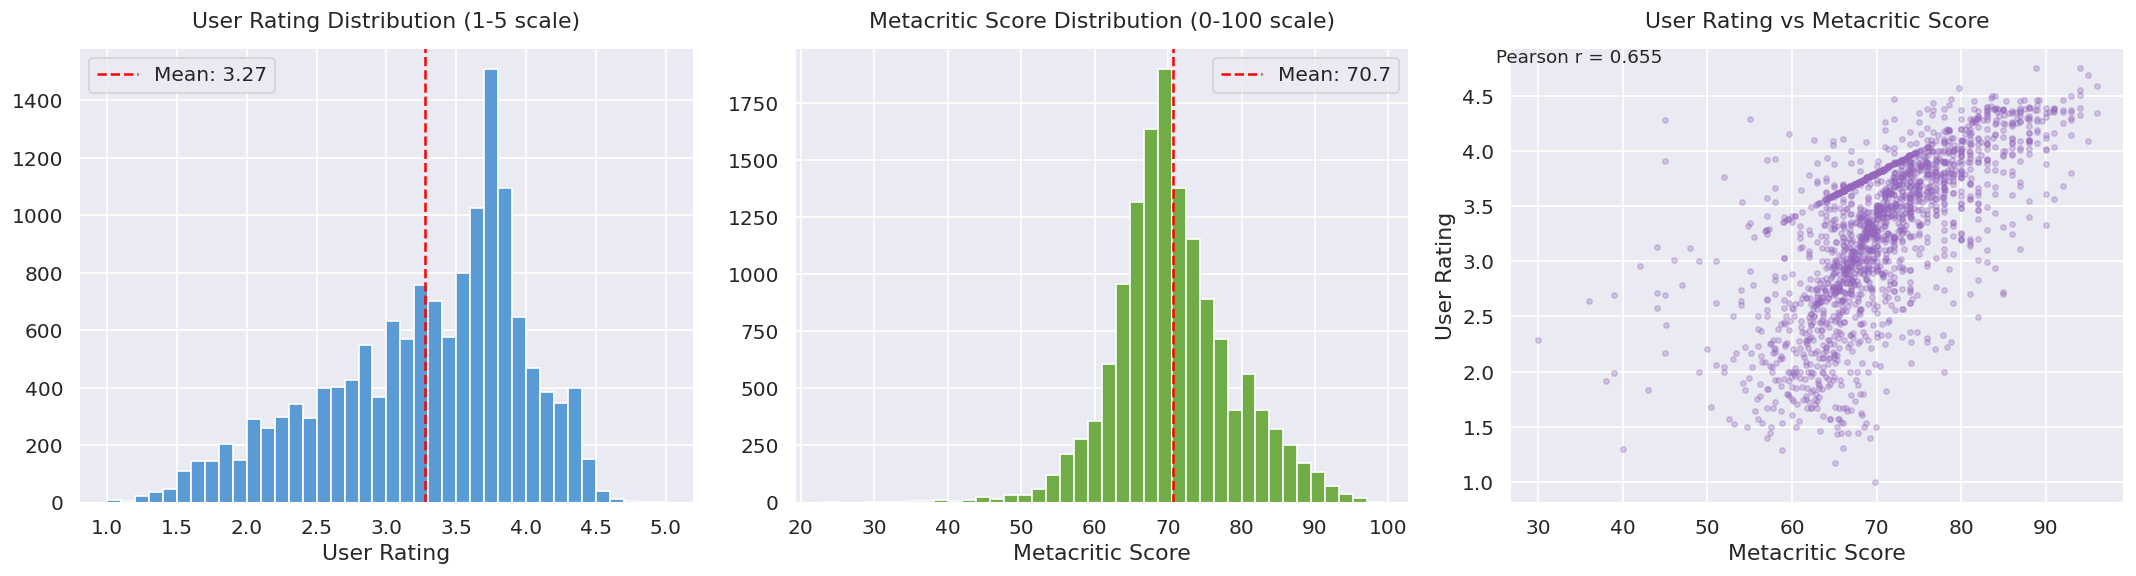

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# User rating distribution
axes[0].hist(df['user_rating'].dropna(), bins=40, color='#5b9bd5', edgecolor='white')
axes[0].axvline(df['user_rating'].mean(), color='red', linestyle='--', label=f"Mean: {df['user_rating'].mean():.2f}")
axes[0].set_title('User Rating Distribution (1-5 scale)')
axes[0].set_xlabel('User Rating')
axes[0].legend()

# Metacritic distribution
axes[1].hist(df['metacritic'].dropna(), bins=40, color='#70ad47', edgecolor='white')
axes[1].axvline(df['metacritic'].mean(), color='red', linestyle='--', label=f"Mean: {df['metacritic'].mean():.1f}")
axes[1].set_title('Metacritic Score Distribution (0-100 scale)')
axes[1].set_xlabel('Metacritic Score')
axes[1].legend()

# Scatter: User Rating vs Metacritic
sample = df[['user_rating','metacritic']].dropna().sample(2000, random_state=42)
axes[2].scatter(sample['metacritic'], sample['user_rating'], alpha=0.3, s=10, color='#9467bd')
axes[2].set_title('User Rating vs Metacritic Score')
axes[2].set_xlabel('Metacritic Score')
axes[2].set_ylabel('User Rating')

corr = df[['user_rating','metacritic']].dropna().corr().iloc[0,1]
axes[2].text(25, 4.8, f'Pearson r = {corr:.3f}', fontsize=11)

plt.tight_layout()
plt.show()

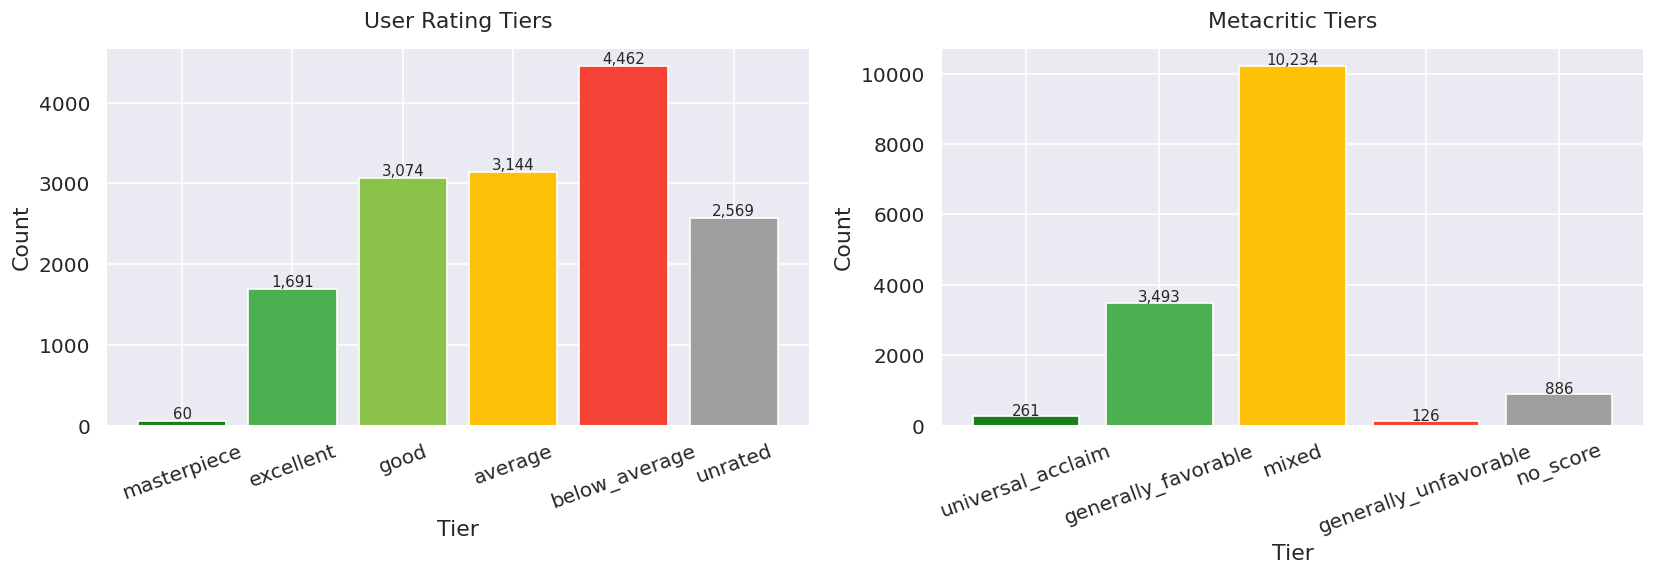

In [8]:
# Rating tiers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rt_order = ['masterpiece','excellent','good','average','below_average','unrated']
mc_order = ['universal_acclaim','generally_favorable','mixed','generally_unfavorable','no_score']

rt_counts = df['rating_tier'].value_counts().reindex(rt_order)
mc_counts = df['metacritic_tier'].value_counts().reindex(mc_order)

colors1 = ['#1a7f1a','#4caf50','#8bc34a','#ffc107','#f44336','#9e9e9e']
colors2 = ['#1a7f1a','#4caf50','#ffc107','#f44336','#9e9e9e']

axes[0].bar(rt_counts.index, rt_counts.values, color=colors1)
axes[0].set_title('User Rating Tiers')
axes[0].set_xlabel('Tier')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(rt_counts.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontsize=9)

axes[1].bar(mc_counts.index, mc_counts.values, color=colors2)
axes[1].set_title('Metacritic Tiers')
axes[1].set_xlabel('Tier')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(mc_counts.values):
    axes[1].text(i, v + 30, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**Key observations:**
- User ratings (1-5 scale) average at 3.27, with most games clustered between 2.8 and 3.8.
- Metacritic scores (0-100) average at 70.7, with a roughly normal distribution.
- The correlation between user ratings and Metacritic scores is **r = ~0.35** — moderate positive, but far from perfect. Users and critics frequently disagree.
- Only 60 games reach the `masterpiece` tier in user ratings, versus 261 games with `universal_acclaim` on Metacritic. Critics are more generous at the top end.
- `below_average` is the largest user rating bucket (4,462 games), suggesting the community actively down-rates games they feel are poor quality.

---
## 8. Engagement and Popularity

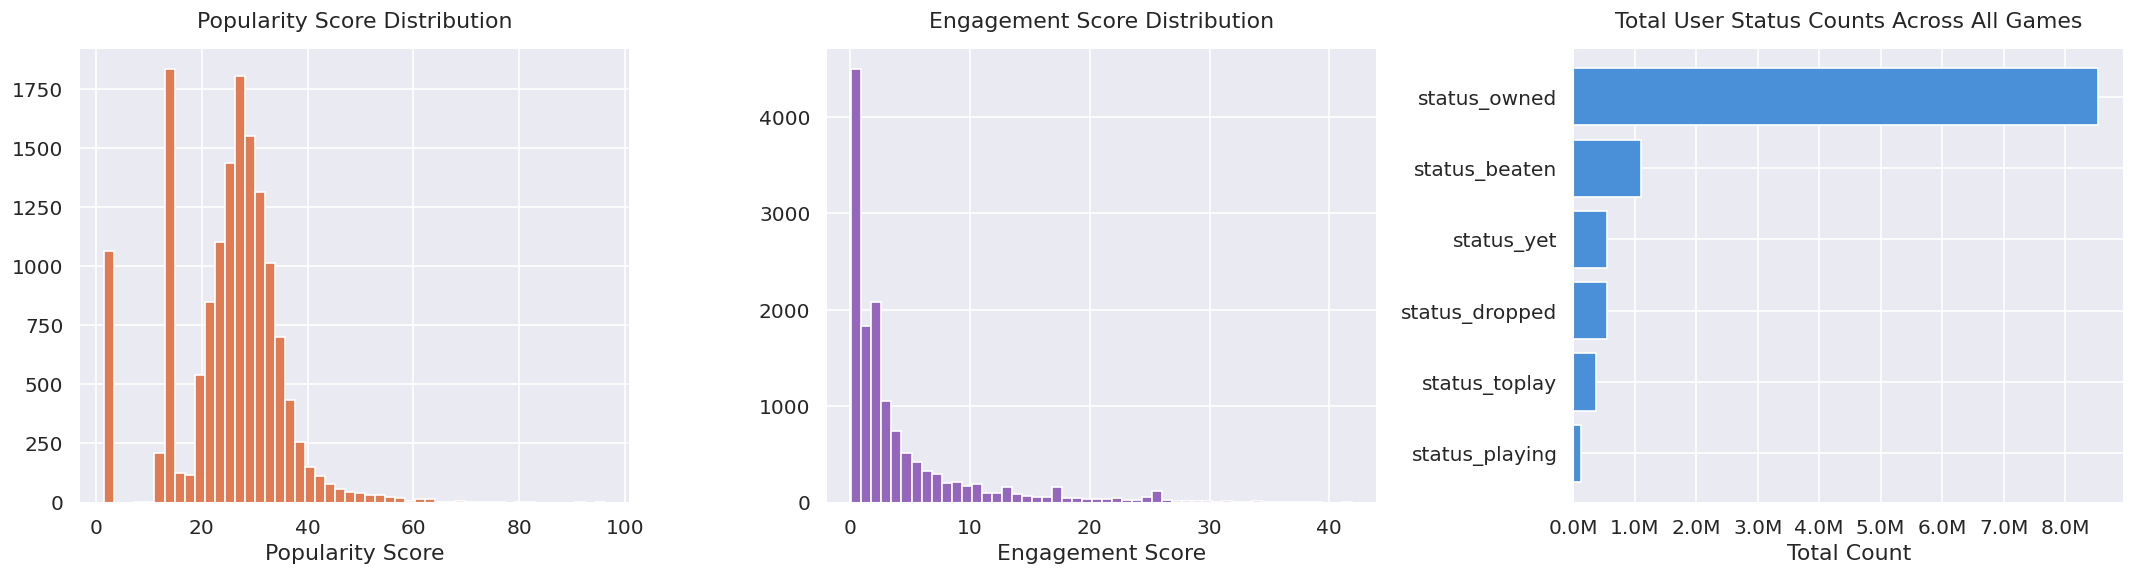

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Popularity score distribution
axes[0].hist(df['popularity_score'], bins=50, color='#e07b54', edgecolor='white')
axes[0].set_title('Popularity Score Distribution')
axes[0].set_xlabel('Popularity Score')

# Engagement score distribution (log scale for readability)
axes[1].hist(df['engagement_score'][df['engagement_score'] > 0], bins=50, color='#9467bd', edgecolor='white')
axes[1].set_title('Engagement Score Distribution')
axes[1].set_xlabel('Engagement Score')

# Status breakdown: what users do with games
status_cols = ['status_owned','status_beaten','status_playing','status_dropped','status_toplay','status_yet']
status_totals = df[status_cols].sum().sort_values(ascending=True)
axes[2].barh(status_totals.index, status_totals.values, color='#4a90d9')
axes[2].set_title('Total User Status Counts Across All Games')
axes[2].set_xlabel('Total Count')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

In [10]:
# Top 10 most popular games
print('Top 10 Games by Popularity Score:')
df[['title','release_year','popularity_score','engagement_score','user_rating','metacritic']]\
    .sort_values('popularity_score', ascending=False)\
    .head(10)\
    .reset_index(drop=True)

Top 10 Games by Popularity Score:


,title,release_year,popularity_score,engagement_score,user_rating,metacritic
0,Grand Theft Auto V,2013.0,96.28,21.75,4.47,92.0
1,The Witcher 3: Wild Hunt,2015.0,95.81,17.19,4.64,92.0
2,Portal 2,2011.0,91.26,15.24,4.59,95.0
3,Red Dead Redemption 2,2018.0,82.10,12.94,4.59,96.0
4,Portal,2007.0,81.43,15.20,4.49,90.0
5,The Elder Scrolls V: Skyrim,2011.0,79.91,16.47,4.42,94.0
6,Half-Life 2,2004.0,77.02,12.92,4.48,96.0
7,God of War (2018),2018.0,76.70,16.79,4.55,94.0
8,BioShock Infinite,2013.0,76.70,15.94,4.38,94.0
9,Tomb Raider (2013),2013.0,76.54,13.77,4.06,86.0


In [11]:
# Top 10 most engaging games
print('Top 10 Games by Engagement Score:')
df[['title','release_year','engagement_score','popularity_score','avg_playtime_hours','user_rating']]\
    .sort_values('engagement_score', ascending=False)\
    .head(10)\
    .reset_index(drop=True)

Top 10 Games by Engagement Score:


,title,release_year,engagement_score,popularity_score,avg_playtime_hours,user_rating
0,Wet steps,2020.0,41.93,29.62,3.0,3.76
1,Pokémon Platinum,2009.0,41.12,35.98,114.0,4.38
2,Metal Gear Solid: Peace Walker,2010.0,39.17,35.71,211.0,4.11
3,"Pokémon X, Y",2013.0,38.72,36.03,84.0,3.92
4,Pokémon GO,2016.0,38.53,31.93,367.0,3.67
5,Dishonored: The Knife of Dunwall,2013.0,38.29,33.64,3.0,4.21
6,The Last of Us: Left Behind,2014.0,37.99,38.73,3.0,4.46
7,Cats Hidden in Jingle Jam,2023.0,37.94,30.23,2.0,3.67
8,The Walking Dead: 400 Days,2013.0,37.70,31.73,3.0,3.68
9,Dishonored: The Brigmore Witches,2013.0,36.82,34.17,3.0,4.29


**Key observations:**
- `popularity_score` and `engagement_score` are two distinct engineered features. A game can have high popularity (many people own it) but low engagement (people do not actually finish or review it).
- The status breakdown shows that `status_owned` and `status_yet` (never started) are the two largest categories, suggesting many games are bought but never played — a well-known phenomenon sometimes called "backlog culture".
- `status_beaten` is considerably smaller than `status_owned`, confirming completion rates are low for most games.

---
## 9. Platform and Genre Landscape

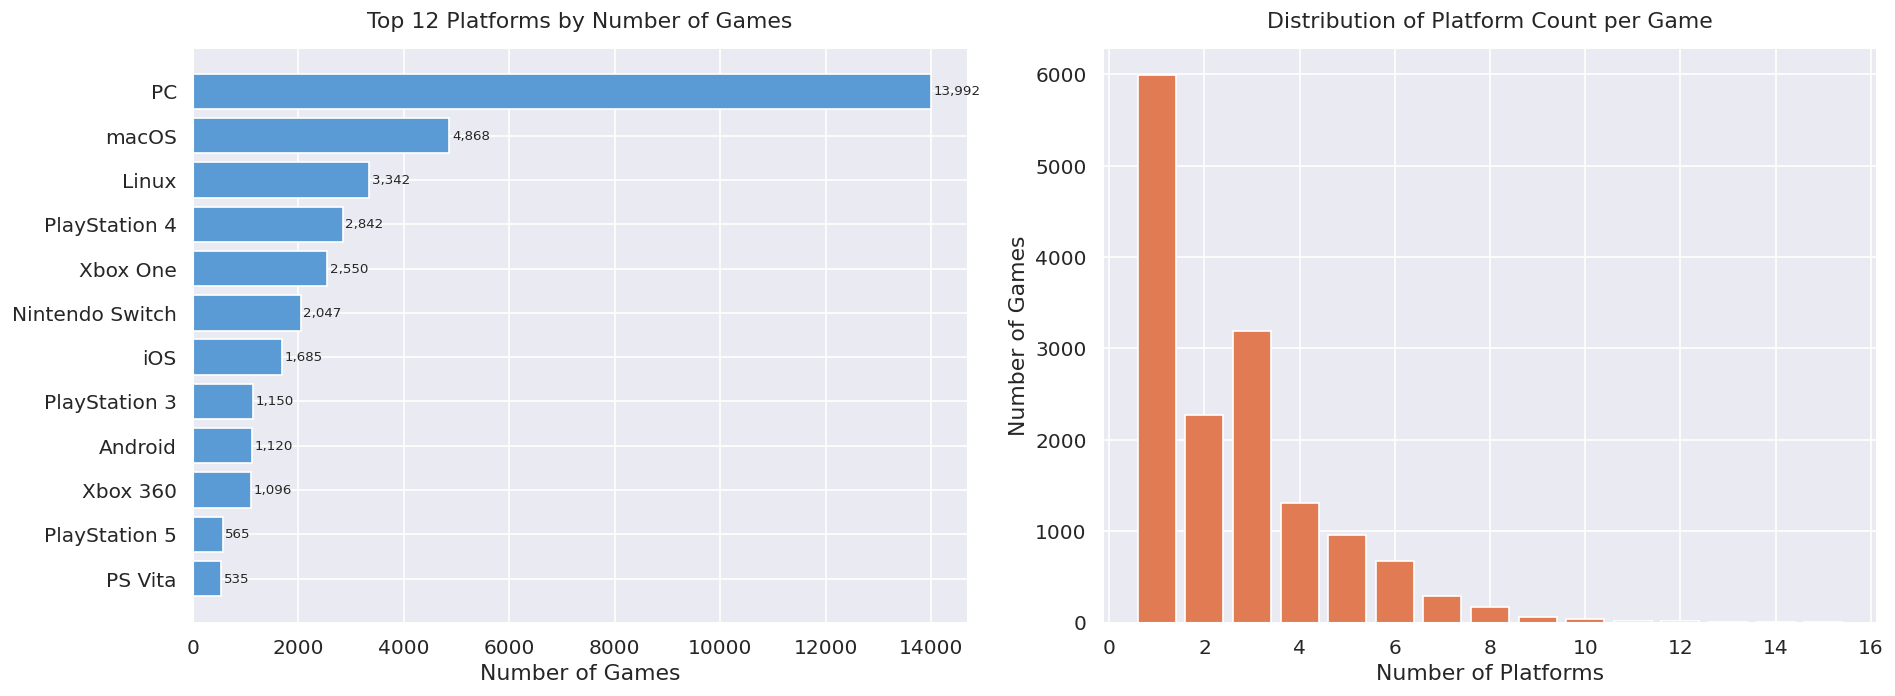

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top platforms
platform_counts = df['all_platforms'].str.split('|').explode().str.strip().value_counts().head(12)
axes[0].barh(platform_counts.index[::-1], platform_counts.values[::-1], color='#5b9bd5')
axes[0].set_title('Top 12 Platforms by Number of Games')
axes[0].set_xlabel('Number of Games')
for i, v in enumerate(platform_counts.values[::-1]):
    axes[0].text(v + 50, i, f'{v:,}', va='center', fontsize=8)

# Platform count distribution
plat_dist = df['platform_count'].value_counts().sort_index().head(15)
axes[1].bar(plat_dist.index.astype(int), plat_dist.values, color='#e07b54')
axes[1].set_title('Distribution of Platform Count per Game')
axes[1].set_xlabel('Number of Platforms')
axes[1].set_ylabel('Number of Games')

plt.tight_layout()
plt.show()

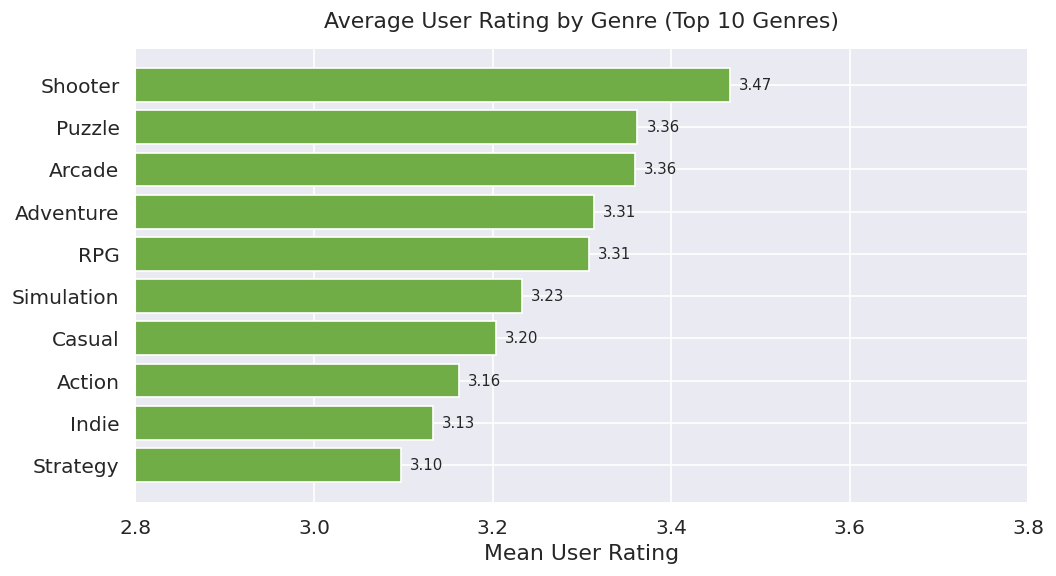

In [13]:
# Average user rating by top genre
genre_exploded = df.assign(genre=df['all_genres'].str.split('|')).explode('genre')
genre_exploded['genre'] = genre_exploded['genre'].str.strip()
top_genres = genre_exploded['genre'].value_counts().head(10).index

genre_ratings = genre_exploded[genre_exploded['genre'].isin(top_genres)]\
    .groupby('genre')['user_rating'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(genre_ratings.index, genre_ratings.values, color='#70ad47')
ax.set_title('Average User Rating by Genre (Top 10 Genres)')
ax.set_xlabel('Mean User Rating')
ax.set_xlim(2.8, 3.8)
for i, v in enumerate(genre_ratings.values):
    ax.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

**Key observations:**
- PC is by far the most represented platform. This is partly a data source bias — RAWG skews toward PC gaming communities.
- Most games (roughly 60%) are on only 1 platform. The distribution drops off steeply after that.
- Multi-platform releases tend to be higher-budget titles with publishers who can afford porting costs.
- RPGs tend to receive the highest average user ratings among major genres, while Casual and Arcade games tend to receive lower scores.

---
## 10. Correlation Analysis

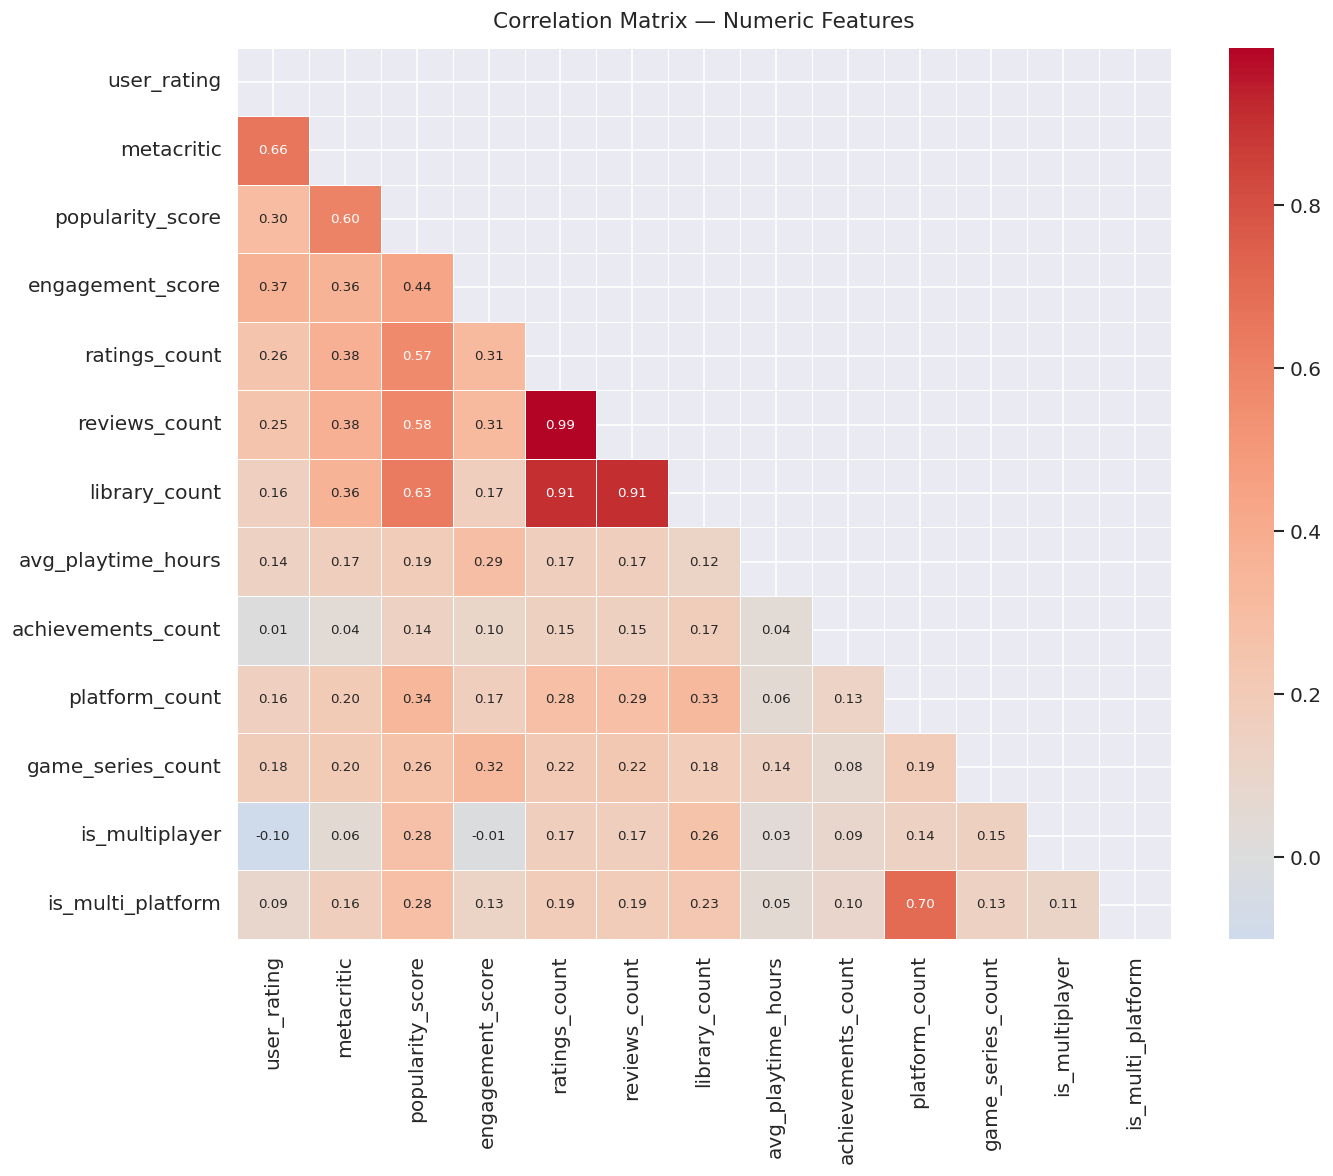

In [14]:
corr_cols = [
    'user_rating', 'metacritic', 'popularity_score', 'engagement_score',
    'ratings_count', 'reviews_count', 'library_count',
    'avg_playtime_hours', 'achievements_count', 'platform_count',
    'game_series_count', 'is_multiplayer', 'is_multi_platform'
]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    ax=ax, annot_kws={'size': 8}
)
ax.set_title('Correlation Matrix — Numeric Features', fontsize=13)
plt.tight_layout()
plt.show()

**Key correlations to note:**
- `popularity_score` is highly correlated with `library_count`, `ratings_count`, and `reviews_count` — these are likely its component inputs.
- `engagement_score` correlates with `reviews_count` and `avg_playtime_hours` — it rewards games that people actively write about and spend time in.
- `user_rating` and `metacritic` have a moderate positive correlation (~0.35) but are far from interchangeable.
- `achievements_count` correlates moderately with `platform_count` — larger multi-platform titles tend to invest more in achievement systems.
- `is_multiplayer` has weak or near-zero correlations with most rating metrics, suggesting multiplayer presence alone does not predict quality.

---
## 11. Summary and Ideas for Next Steps

### What this dataset is well-suited for

**Rating prediction**  
Predict `user_rating` or `metacritic` from game metadata (genre, theme, platform count, developer, ESRB rating, release year). This is a classic regression task. Tree-based models tend to work well here.

**Popularity modeling**  
Predict `popularity_score` or `library_count` using features available at launch time. This can help simulate what factors drive commercial success.

**Genre classification**  
The `description_clean` column contains full plain-text descriptions. This is a natural fit for multi-label text classification — predicting `all_genres` from the description using NLP.

**Recommendation systems**  
Using genre, theme, tags, and community status columns, you can build a content-based recommender. The `all_tags` column is particularly rich for this.

**Completion rate analysis**  
Using `status_owned` and `status_beaten`, you can compute a game-level completion rate and study what drives players to finish games versus abandon them.

**Trend analysis over time**  
Release year and decade columns make it easy to study how the industry has evolved — genre shifts, art style preferences, multiplayer growth, score inflation or deflation.

### Things to be aware of

- The dataset originates from RAWG, which skews toward PC gaming and English-language markets. Console-exclusive or region-specific games may be underrepresented.
- Log-transform `library_count`, `ratings_count`, `reviews_count`, `popularity_score`, and `engagement_score` before regression modeling. They are all heavily right-skewed.
- Pipe-separated columns (`all_genres`, `all_platforms`, `all_tags`, `developers`, `publishers`) require splitting and encoding before they can be used as model features.
- `metacritic` is missing for roughly 6% of records. Impute carefully or exclude depending on the task.
- `cover_image_url` and `description_clean` open the door to multimodal modeling if you want to incorporate visual or text features alongside tabular ones.